# 03 — Model Training Exploration
Trains XGBoost and LightGBM with a small Optuna HPO search (few trials) to explore:
- HPO optimization history
- Best hyperparameters
- CV AUC across folds
- Training vs validation AUC curve
- Class imbalance handling with `scale_pos_weight`

> **Note:** `src/train.py` does the full 50-trial search + MLflow logging. This notebook is for exploration only.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src.features import prepare_features, build_full_pipeline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

SEED = 42
N_TRIALS = 10  # small for exploration; src/train.py uses 50
CV_FOLDS = 3

In [2]:
with open('../params.yaml') as f:
    params = yaml.safe_load(f)

train_df = pd.read_parquet(f"../{params['data']['train_path']}")
X_train, y_train = prepare_features(train_df, params_path='../params.yaml')

# class imbalance ratio
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Train size: {len(X_train):,}")
print(f"Default rate: {y_train.mean():.4f}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Train size: 631,361
Default rate: 0.0697
scale_pos_weight: 13.35


## 1. XGBoost — Optuna HPO

In [3]:
def xgb_objective(trial, X, y, cv_folds, seed, scale_pos_weight):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': seed,
        'eval_metric': 'auc',
        'tree_method': 'hist',
    }
    model = build_full_pipeline(XGBClassifier(**params))
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()


xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(
    lambda trial: xgb_objective(trial, X_train, y_train, CV_FOLDS, SEED, scale_pos_weight),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print(f"\nBest XGB AUC: {xgb_study.best_value:.4f}")
print("Best params:", xgb_study.best_params)

  0%|          | 0/10 [00:00<?, ?it/s]


Best XGB AUC: 0.9944
Best params: {'n_estimators': 173, 'max_depth': 4, 'learning_rate': 0.05958389350068958, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167}


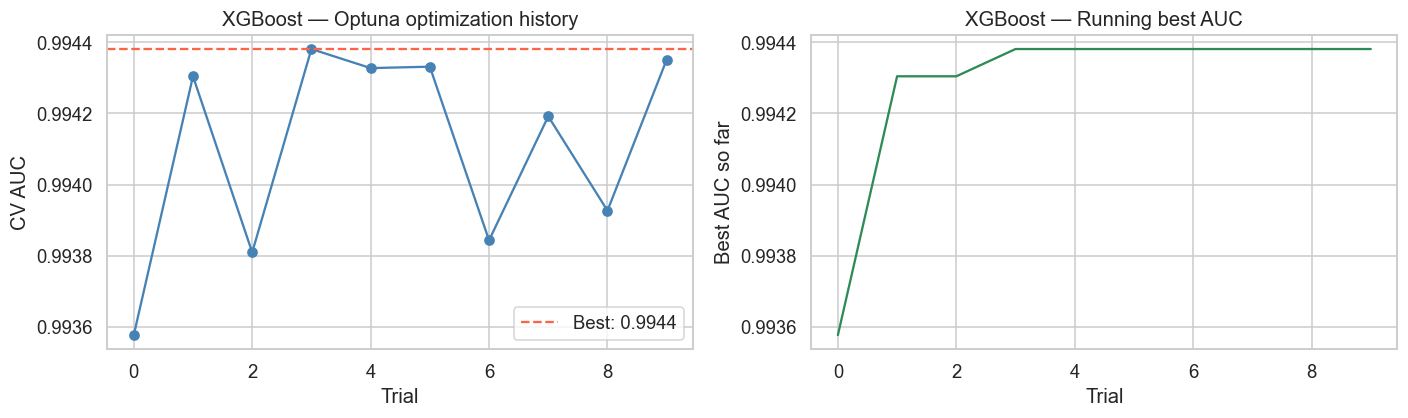

In [4]:
# HPO history
xgb_df = xgb_study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(xgb_df['number'], xgb_df['value'], marker='o', color='steelblue')
axes[0].axhline(xgb_study.best_value, color='tomato', linestyle='--', label=f'Best: {xgb_study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV AUC')
axes[0].set_title('XGBoost — Optuna optimization history')
axes[0].legend()

axes[1].plot(xgb_df['number'], xgb_df['value'].cummax(), marker='', color='seagreen')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Best AUC so far')
axes[1].set_title('XGBoost — Running best AUC')

plt.tight_layout()
plt.show()

## 2. LightGBM — Optuna HPO

In [5]:
def lgbm_objective(trial, X, y, cv_folds, seed, scale_pos_weight):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': seed,
        'verbosity': -1,
    }
    model = build_full_pipeline(LGBMClassifier(**params))
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()


lgbm_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
lgbm_study.optimize(
    lambda trial: lgbm_objective(trial, X_train, y_train, CV_FOLDS, SEED, scale_pos_weight),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print(f"\nBest LGBM AUC: {lgbm_study.best_value:.4f}")
print("Best params:", lgbm_study.best_params)

  0%|          | 0/10 [00:00<?, ?it/s]


Best LGBM AUC: 0.9944
Best params: {'n_estimators': 222, 'max_depth': 3, 'learning_rate': 0.1024932221692416, 'num_leaves': 77, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508}


## 3. Model comparison

In [6]:
comparison = pd.DataFrame([
    {'Model': 'XGBoost', 'Best CV AUC': xgb_study.best_value, 'Trials': len(xgb_study.trials)},
    {'Model': 'LightGBM', 'Best CV AUC': lgbm_study.best_value, 'Trials': len(lgbm_study.trials)},
])
comparison['Best CV AUC'] = comparison['Best CV AUC'].map('{:.4f}'.format)
comparison

,Model,Best CV AUC,Trials
0,XGBoost,0.9944,10
1,LightGBM,0.9944,10


## 4. Final model — CV fold scores

Fold AUCs: [0.9943 0.9944 0.9945]
Mean: 0.9944  Std: 0.0001


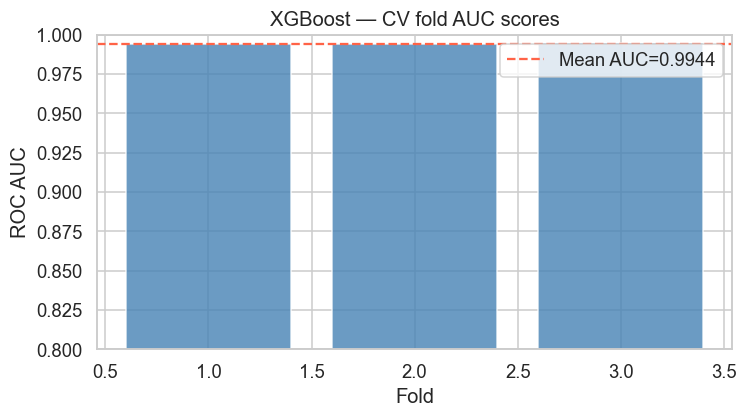

In [7]:
# Train best XGBoost with full CV to inspect fold variance
best_xgb_params = {**xgb_study.best_params, 'scale_pos_weight': scale_pos_weight,
                   'random_state': SEED, 'eval_metric': 'auc', 'tree_method': 'hist'}
best_model = build_full_pipeline(XGBClassifier(**best_xgb_params))

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Fold AUCs: {fold_scores.round(4)}")
print(f"Mean: {fold_scores.mean():.4f}  Std: {fold_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(fold_scores) + 1), fold_scores, color='steelblue', alpha=0.8)
ax.axhline(fold_scores.mean(), color='tomato', linestyle='--', label=f'Mean AUC={fold_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC AUC')
ax.set_title('XGBoost — CV fold AUC scores')
ax.legend()
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

## 5. Hyperparameter importance

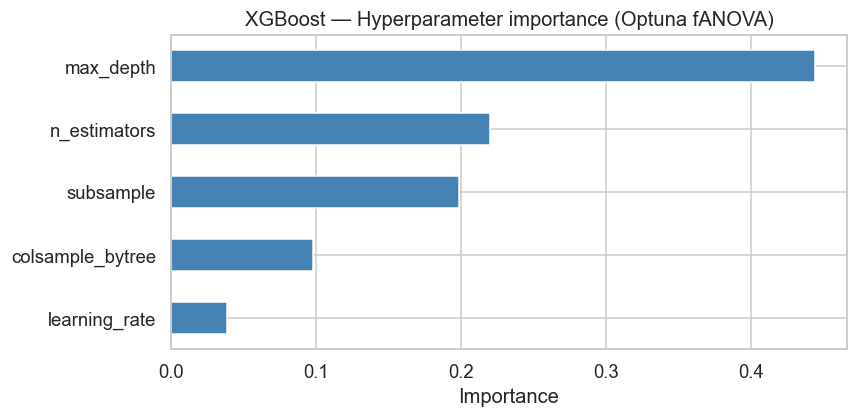

In [8]:
try:
    importances = optuna.importance.get_param_importances(xgb_study)
    imp_df = pd.Series(importances).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    imp_df.plot.barh(ax=ax, color='steelblue')
    ax.set_title('XGBoost — Hyperparameter importance (Optuna fANOVA)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Importance plot requires more trials: {e}")